# 02 - Model Training
## CICDDoS2019 Multi-Class DDoS Detection

**Input:** cleaned_train.pkl
**Output:** xgboost_ddos_model.json, feature_importance.csv, training_results.pkl

In [1]:
import pandas as pd
import numpy as np
import pickle
import time
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
print('OK')

OK


## 1. Load & Fix Labels

In [2]:
with open('../data/cleaned_train.pkl', 'rb') as f:
    train_data = pickle.load(f)

X_train = train_data['X']
y_train_raw = train_data['y']
feature_names = train_data['feature_names']
all_classes = train_data['classes']

# Re-encode labels to 0..N-1 (some classes may be missing in training)
unique_labels = sorted(np.unique(y_train_raw))
classes = [all_classes[i] for i in unique_labels]
label_map = {old: new for new, old in enumerate(unique_labels)}
y_train = np.array([label_map[y] for y in y_train_raw])
NUM_CLASSES = len(classes)

print(f'Training: {X_train.shape[0]:,} samples, {X_train.shape[1]} features')
print(f'Classes ({NUM_CLASSES}): {classes}')
for i, c in enumerate(classes):
    print(f'  {i}: {c} = {(y_train==i).sum():,}')

Training: 319,286 samples, 82 features
Classes (13): [np.str_('BENIGN'), np.str_('DNS'), np.str_('LDAP'), np.str_('MSSQL'), np.str_('NETBIOS'), np.str_('NTP'), np.str_('SNMP'), np.str_('SSDP'), np.str_('SYN'), np.str_('TFTP'), np.str_('UDP'), np.str_('UDP-LAG'), np.str_('WEBDDOS')]
  0: BENIGN = 6,039
  1: DNS = 28,224
  2: LDAP = 29,225
  3: MSSQL = 29,232
  4: NETBIOS = 28,716
  5: NTP = 26,058
  6: SNMP = 29,500
  7: SSDP = 29,613
  8: SYN = 27,436
  9: TFTP = 27,681
  10: UDP = 29,343
  11: UDP-LAG = 28,096
  12: WEBDDOS = 123


## 2. 5-Fold Cross-Validation

In [3]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

# XGBoost
xgb_model = XGBClassifier(
    objective='multi:softmax', num_class=NUM_CLASSES,
    max_depth=6, learning_rate=0.3, n_estimators=100,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
print('XGBoost 5-Fold CV...')
t0 = time.time()
xgb_cv = cross_validate(xgb_model, X_train, y_train, cv=skf,
                         scoring=scoring, n_jobs=-1)
print(f'  Done in {time.time()-t0:.1f}s')

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
print('Random Forest 5-Fold CV...')
t0 = time.time()
rf_cv = cross_validate(rf_model, X_train, y_train, cv=skf,
                        scoring=scoring, n_jobs=-1)
print(f'  Done in {time.time()-t0:.1f}s')

XGBoost 5-Fold CV...
  Done in 149.5s
Random Forest 5-Fold CV...
  Done in 108.7s


In [4]:
print('\n' + '='*70)
print('  5-FOLD CV RESULTS (Macro Average)')
print('='*70)
print(f'{"Method":15s} {"Acc%":>10s} {"Prec%":>10s} {"Rec%":>10s} {"F1%":>10s}')
print('-'*70)
for name, cv in [('XGBoost', xgb_cv), ('Random Forest', rf_cv)]:
    a = cv['test_accuracy'].mean()*100
    p = cv['test_precision_macro'].mean()*100
    r = cv['test_recall_macro'].mean()*100
    f = cv['test_f1_macro'].mean()*100
    a_s = cv['test_accuracy'].std()*100
    f_s = cv['test_f1_macro'].std()*100
    print(f'{name:15s} {a:.2f}+/-{a_s:.2f} {p:.2f}      {r:.2f}      {f:.2f}+/-{f_s:.2f}')
print('='*70)


  5-FOLD CV RESULTS (Macro Average)
Method                Acc%      Prec%       Rec%        F1%
----------------------------------------------------------------------
XGBoost         86.55+/-0.15 85.29      84.27      84.42+/-0.51
Random Forest   84.60+/-0.08 83.22      81.70      82.18+/-0.94


## 3. Train Final Model

In [5]:
xgb_final = XGBClassifier(
    objective='multi:softmax', num_class=NUM_CLASSES,
    max_depth=6, learning_rate=0.3, n_estimators=100,
    eval_metric='mlogloss', random_state=42, n_jobs=-1
)
print('Training final model...')
t0 = time.time()
xgb_final.fit(X_train, y_train)
print(f'Done in {time.time()-t0:.1f}s')

y_pred = xgb_final.predict(X_train)
print(f'Train acc: {accuracy_score(y_train, y_pred)*100:.2f}%')
print(f'Train F1:  {f1_score(y_train, y_pred, average="macro")*100:.2f}%')

Training final model...
Done in 53.3s
Train acc: 87.78%
Train F1:  89.59%


## 4. Feature Importance

In [6]:
importance = xgb_final.feature_importances_
feat_imp = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feat_imp = feat_imp.sort_values('Importance', ascending=False).reset_index(drop=True)

print('Top 15 Features:')
print(feat_imp.head(15).to_string(index=False))

top_10 = feat_imp.head(10)['Feature'].tolist()
print(f'\nTop 10 for deployment: {top_10}')

feat_imp.to_csv('../data/feature_importance.csv', index=False)

Top 15 Features:
                Feature  Importance
         ACK Flag Count    0.194913
      Min Packet Length    0.111674
            Fwd IAT Max    0.105258
Init_Win_bytes_backward    0.065606
       act_data_pkt_fwd    0.059334
 Init_Win_bytes_forward    0.054033
                Inbound    0.035625
  Bwd Packet Length Std    0.032541
     Packet Length Mean    0.031177
         URG Flag Count    0.027788
  Fwd Packet Length Std    0.026988
      Subflow Fwd Bytes    0.021891
   Avg Fwd Segment Size    0.020330
    Average Packet Size    0.019239
  Bwd Packet Length Max    0.013878

Top 10 for deployment: ['ACK Flag Count', 'Min Packet Length', 'Fwd IAT Max', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'Init_Win_bytes_forward', 'Inbound', 'Bwd Packet Length Std', 'Packet Length Mean', 'URG Flag Count']


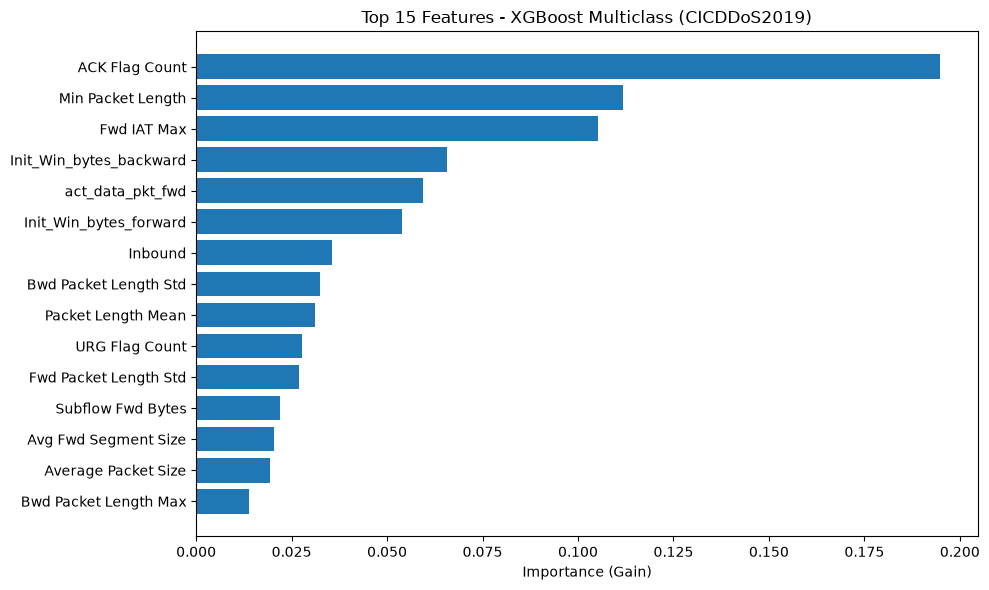

In [7]:
# Plot
top_n = 15
plt.figure(figsize=(10, 6))
top = feat_imp.head(top_n)
plt.barh(range(top_n), top['Importance'].values[::-1])
plt.yticks(range(top_n), top['Feature'].values[::-1])
plt.xlabel('Importance (Gain)')
plt.title('Top 15 Features - XGBoost Multiclass (CICDDoS2019)')
plt.tight_layout()
plt.savefig('../data/feature_importance_top15.png', dpi=150)
plt.show()

## 5. Save Model & Results

In [8]:
import xgboost as xgb

os.makedirs('../models', exist_ok=True)
model_path = '../models/xgboost_ddos_model.json'
xgb_final.save_model(model_path)
model_size = os.path.getsize(model_path) / 1024

# Inference time
booster = xgb_final.get_booster()
test_dm = xgb.DMatrix(X_train.iloc[:100])
times = []
for _ in range(10):
    t0 = time.time()
    booster.predict(test_dm)
    times.append((time.time()-t0)*1000)
avg_inf = np.mean(times)

print(f'Model size: {model_size:.1f} KB')
print(f'Inference (100 samples): {avg_inf:.1f} ms')

# Save results
results = {
    'cv_xgboost': {k: v.tolist() for k,v in xgb_cv.items() if 'test_' in k},
    'cv_rf': {k: v.tolist() for k,v in rf_cv.items() if 'test_' in k},
    'top_10_features': top_10,
    'model_size_kb': model_size,
    'inference_ms': avg_inf,
    'num_classes': NUM_CLASSES,
    'classes': classes,
    'label_map': label_map
}
with open('../data/training_results.pkl', 'wb') as f:
    pickle.dump(results, f)

print('\nAll saved. Proceed to notebook 03.')

Model size: 4897.6 KB
Inference (100 samples): 0.8 ms

All saved. Proceed to notebook 03.
